# 2D Molecular Dynamics for Problems 8.6 and 8.11

This notebook contains my work for the two problems my group is assigned. It's organized into two parts:

1. **Prerequisites** (Section 1): the core functions I'll reuse everywhere.
2. **Problems** (Sections 2 to 5): the actual sub-problems for 8.6(a), 8.6(b), 8.11(a), and 8.11(b), still working on the rest of the problems

Everything uses reduced units for now (is this correct): $\epsilon = \sigma = m = k_B = 1$.

## 1. Core Functions

Core functions I built on top of the Verlet algorithm work from earlier in the class. Everything is 2D, the Lennard-Jones force function also returns potential energy and virial, and I added save/load for configurations.

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [48]:
def distance_matrix_2d(x, y, Lx, Ly):
    # Pairwise separations with minimum image convention. Returns squared distances.
    dx = x[:, None] - x[None, :]
    dy = y[:, None] - y[None, :]
    dx -= Lx * np.round(dx / Lx)
    dy -= Ly * np.round(dy / Ly)
    r2 = dx * dx + dy * dy
    return dx, dy, r2


def lj_force_2d(x, y, Lx, Ly):
    # 2D Lennard-Jones. Returns forces (= accelerations since m=1), PE, and virial.
    dx, dy, r2 = distance_matrix_2d(x, y, Lx, Ly)
    np.fill_diagonal(r2, np.inf)  # kill self-interaction
    inv_r2  = 1.0 / r2
    inv_r6  = inv_r2 ** 3
    inv_r12 = inv_r6 ** 2
    f_over_r2 = 24.0 * (2.0 * inv_r12 - inv_r6) * inv_r2
    fx = np.sum(f_over_r2 * dx, axis=1)
    fy = np.sum(f_over_r2 * dy, axis=1)
    PE = 0.5 * np.sum(4.0 * (inv_r12 - inv_r6))           # 0.5 to avoid double counting
    virial = 0.5 * np.sum(24.0 * (2.0 * inv_r12 - inv_r6))
    return fx, fy, PE, virial


def verlet_step_2d(state, Lx, Ly, dt):
    # One velocity-Verlet step. Mutates state in place. Returns (PE, virial).
    state['x'] += state['vx'] * dt + 0.5 * state['ax'] * dt * dt
    state['y'] += state['vy'] * dt + 0.5 * state['ay'] * dt * dt
    state['x'] %= Lx  # periodic boundaries
    state['y'] %= Ly
    ax_new, ay_new, PE, vir = lj_force_2d(state['x'], state['y'], Lx, Ly)
    state['vx'] += 0.5 * (ax_new + state['ax']) * dt
    state['vy'] += 0.5 * (ay_new + state['ay']) * dt
    state['ax'] = ax_new
    state['ay'] = ay_new
    return PE, vir

In [49]:
def set_triangular_lattice(N, Lx, Ly):
    # Python translation of Listing 8.13. For a perfect lattice use Ly = sqrt(3)/2 * Lx.
    nx = int(round(np.sqrt(N)))
    ny = int(round(N / nx))
    assert nx * ny == N
    dx = Lx / nx
    dy = Ly / ny
    x = np.zeros(N)
    y = np.zeros(N)
    for ix in range(nx):
        for iy in range(ny):
            i = ix + iy * nx  # book has iy*ny, which is wrong for nx != ny
            y[i] = dy * (iy + 0.5)
            x[i] = dx * (ix + (0.25 if iy % 2 == 0 else 0.75))
    return x, y


def set_rectangular_lattice(N, Lx, Ly):
    # Simple grid. Use for liquids where crystal symmetry doesn't matter.
    nx = int(round(np.sqrt(N)))
    ny = int(round(N / nx))
    dx = Lx / nx
    dy = Ly / ny
    xs = (np.arange(nx) + 0.5) * dx
    ys = (np.arange(ny) + 0.5) * dy
    X, Y = np.meshgrid(xs, ys)
    return X.flatten(), Y.flatten()

In [50]:
def initial_velocities(N, T, rng):
    # Random velocities, zero center-of-mass drift, rescaled to target T.
    vx = rng.uniform(-1, 1, N)
    vy = rng.uniform(-1, 1, N)
    vx -= vx.mean()
    vy -= vy.mean()
    KE = 0.5 * np.sum(vx * vx + vy * vy)
    if KE > 0:
        scale = np.sqrt(N * T / KE)   # 2D equipartition: <KE> = N*T
        vx *= scale
        vy *= scale
    return vx, vy


def make_state(x, y, vx, vy, Lx, Ly):
    # Build the state dict and compute initial accelerations.
    s = {'x': x.copy(), 'y': y.copy(),
         'vx': vx.copy(), 'vy': vy.copy(),
         'ax': np.zeros_like(x), 'ay': np.zeros_like(y)}
    s['ax'], s['ay'], _, _ = lj_force_2d(s['x'], s['y'], Lx, Ly)
    return s


def kinetic_energy(state):
    return 0.5 * np.sum(state['vx']**2 + state['vy']**2)


def temperature(state):
    return kinetic_energy(state) / len(state['x'])   # 2D: T = KE / N


def pressure(state, Lx, Ly, virial):
    N = len(state['x'])
    return (N * temperature(state) + 0.5 * virial) / (Lx * Ly)

In [51]:
def save_state(path, state, Lx, Ly, extra=None):
    # Pickle the state dict plus box dimensions and any metadata.
    blob = {'state': {k: v.copy() for k, v in state.items()},
            'Lx': Lx, 'Ly': Ly, 'extra': extra or {}}
    with open(path, 'wb') as f:
        pickle.dump(blob, f)


def load_state(path):
    with open(path, 'rb') as f:
        blob = pickle.load(f)
    return blob['state'], blob['Lx'], blob['Ly'], blob['extra']

### Quick energy-conservation check

This is basically Problem 8.5. If total energy drifts, nothing downstream is trustworthy, so I run a short simulation first and confirm the drift is small.

<E> = -56.4396,  relative drift = 2.05e-03  (want < 1e-3)


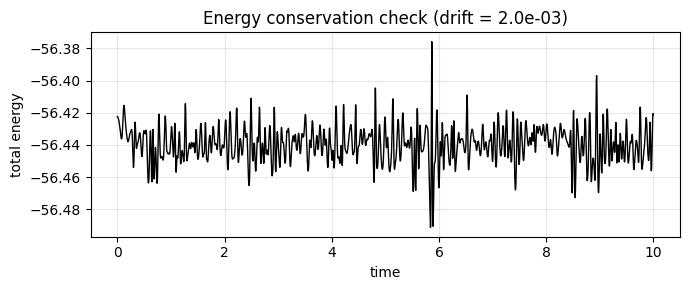

In [52]:
# Short validation run: N=64 liquid at T=1, check that E = KE + PE stays constant.
rng = np.random.default_rng(42)
N, Lx, Ly = 64, 10.0, 10.0
x, y = set_rectangular_lattice(N, Lx, Ly)
vx, vy = initial_velocities(N, T=1.0, rng=rng)
state = make_state(x, y, vx, vy, Lx, Ly)

dt = 0.005
E_arr = []
for step in range(2000):
    PE, _ = verlet_step_2d(state, Lx, Ly, dt)
    E_arr.append(kinetic_energy(state) + PE)

E_arr = np.array(E_arr)
drift = (E_arr.max() - E_arr.min()) / abs(E_arr.mean())
print(f"<E> = {E_arr.mean():.4f},  relative drift = {drift:.2e}  (want < 1e-3)")

plt.figure(figsize=(7, 3))
plt.plot(np.arange(len(E_arr)) * dt, E_arr, 'k', lw=1)
plt.xlabel('time'); plt.ylabel('total energy'); plt.grid(alpha=0.3)
plt.title(f'Energy conservation check (drift = {drift:.1e})')
plt.tight_layout()
plt.show()

---

## 2. Problem 8.6(a): distribution of velocity components

**What the problem asks me:**
1. Compute the probability density $P(v_x)$ (the probability per unit $v_x$ of finding a particle with a given x-velocity).
2. Compute $P(v_y)$ the same way.
3. Find the most probable values and average values of $v_x$ and $v_y$.
4. Plot both distributions and also plot the average $\frac{1}{2}[P(v_x{=}u) + P(v_y{=}u)]$. That average is smoother because it has effectively twice the sample count.
5. Describe the qualitative form of these distributions.

**What I expect to find:** Each component should be Gaussian-distributed with mean zero and standard deviation $\sqrt{T}$ in reduced units. That's the Maxwell-Boltzmann prediction for velocity components in thermal equilibrium. The most probable and average values should both be essentially zero by symmetry.

**The code:** The hint was to just use `matplotlib.hist`:
1. Set up a liquid-like system (density around 0.64).
2. Run 'equilibration' steps that I throw away, so the system forgets about its artificial starting grid.
3. Run 'production' steps. Every few steps, save all $N$ velocity components.
4. Histogram the collected samples.

In [53]:
# Set up the system
rng = np.random.default_rng(7)       # fixed seed so results are reproducible

N = 64                               # number of particles (from the textbook examples)
Lx = Ly = 10.0                       # box is 10 x 10, giving density 64/100 = 0.64 (liquid-like)

x, y = set_rectangular_lattice(N, Lx, Ly)        # start particles on a simple grid
vx, vy = initial_velocities(N, T=1.0, rng=rng)   # give them random velocities at target T = 1
state = make_state(x, y, vx, vy, Lx, Ly)         # package into state dict with initial forces

In [54]:
# Equilibration phase (throw away)
# I run the integrator WITHOUT saving anything. This lets the system
# relax from the artificial starting grid into a real liquid configuration.
# If I skipped this, my histograms would be biased by the starting grid.

dt = 0.005                           # time step that passed the energy check
n_equil = 2000                       # 2000 * 0.005 = 10 reduced time units

for _ in range(n_equil):
    verlet_step_2d(state, Lx, Ly, dt)   # advance one Verlet step, ignore the return values

In [55]:
# Collect Samples
# Now the system is equilibrated, so run more steps and save vx, vy of
# every particle every few steps. Saving every step would be wasteful because
# consecutive steps are highly correlated (the velocities barely change in dt).

n_prod = 4000                        # production steps
sample_every = 5                     # save velocities every 5 steps

vx_samples = []                      # will become a list of 800 arrays, each length 64
vy_samples = []
T_running  = []                      # instantaneous temperature at each sample time

for step in range(n_prod):
    verlet_step_2d(state, Lx, Ly, dt)
    if step % sample_every == 0:
        # .copy() is CRITICAL. Without it, every saved entry would point to the
        # same underlying array that keeps getting overwritten by the next Verlet step.
        vx_samples.append(state['vx'].copy())
        vy_samples.append(state['vy'].copy())
        T_running.append(temperature(state))

# Flatten the list of arrays into one big array per component.
# 800 time samples times 64 particles = 51,200 values per component.
vx_all = np.concatenate(vx_samples)
vy_all = np.concatenate(vy_samples)
T_mean = np.mean(T_running)

# Report the summary statistics.
print(f"Collected {len(vx_all)} samples per component")
print(f"Mean temperature during production: <T> = {T_mean:.4f}")
print()
print(f"<vx>    = {vx_all.mean():+.4f}   (should be ~0: no net drift)")
print(f"<vy>    = {vy_all.mean():+.4f}   (should be ~0: no net drift)")
print(f"std(vx) = {vx_all.std():.4f}")
print(f"std(vy) = {vy_all.std():.4f}")
print(f"sqrt(T) = {np.sqrt(T_mean):.4f}  (this is what the theoretical std should equal)")

Collected 51200 samples per component
Mean temperature during production: <T> = 0.8974

<vx>    = +0.0000   (should be ~0: no net drift)
<vy>    = +0.0000   (should be ~0: no net drift)
std(vx) = 0.9524
std(vy) = 0.9422
sqrt(T) = 0.9473  (this is what the theoretical std should equal)


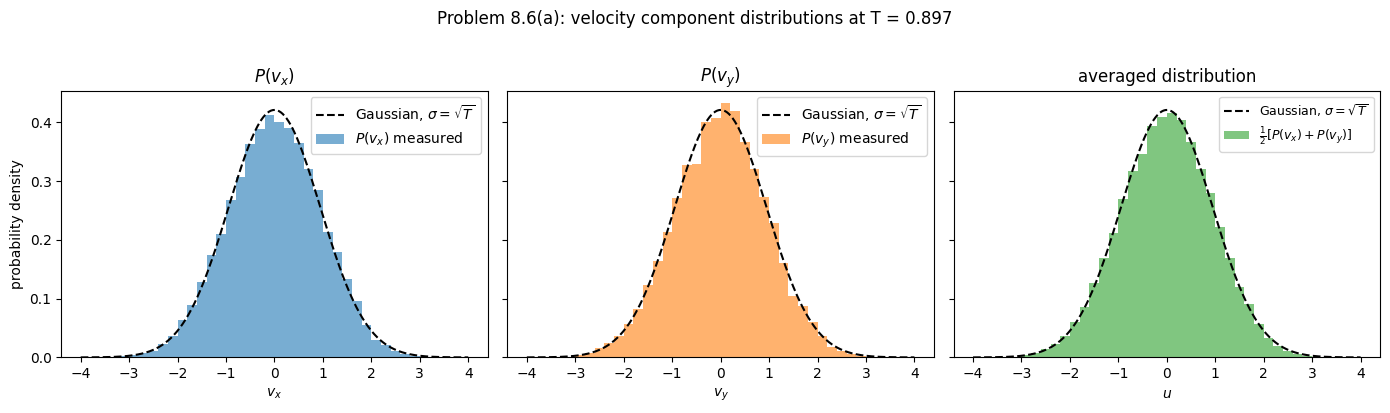

In [56]:
# Build the histograms and plot

# Use the SAME bin edges for vx and vy so I can average them point-by-point.
bins = np.linspace(-4, 4, 41)                      # 40 bins from -4 to +4
bin_centers = 0.5 * (bins[:-1] + bins[1:])         # x coordinate at the middle of each bin
bin_width = bins[1] - bins[0]

# density=True normalizes so the total area under the histogram equals 1.
# This turns it into a probability density function P(vx).
Px, _ = np.histogram(vx_all, bins=bins, density=True)
Py, _ = np.histogram(vy_all, bins=bins, density=True)

# The averaged distribution has effectively twice the sample count.
# By symmetry, both components should have identical distributions, so averaging
# is a valid way to reduce noise (it's what the problem asks for).
P_avg = 0.5 * (Px + Py)

# Theoretical expectation: a Gaussian with mean 0 and variance T.
# This comes from the Maxwell-Boltzmann distribution projected onto one axis.
u_fine = np.linspace(-4, 4, 400)
P_theory = (1.0 / np.sqrt(2 * np.pi * T_mean)) * np.exp(-u_fine**2 / (2 * T_mean))

# Three-panel plot: P(vx), P(vy), and the averaged distribution.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

axes[0].bar(bin_centers, Px, width=bin_width, alpha=0.6, label='$P(v_x)$ measured')
axes[0].plot(u_fine, P_theory, 'k--', label='Gaussian, $\\sigma=\\sqrt{T}$')
axes[0].set_xlabel('$v_x$'); axes[0].set_ylabel('probability density')
axes[0].set_title('$P(v_x)$'); axes[0].legend()

axes[1].bar(bin_centers, Py, width=bin_width, alpha=0.6, color='C1', label='$P(v_y)$ measured')
axes[1].plot(u_fine, P_theory, 'k--', label='Gaussian, $\\sigma=\\sqrt{T}$')
axes[1].set_xlabel('$v_y$'); axes[1].set_title('$P(v_y)$'); axes[1].legend()

axes[2].bar(bin_centers, P_avg, width=bin_width, alpha=0.6, color='C2',
            label=r'$\frac{1}{2}[P(v_x) + P(v_y)]$')
axes[2].plot(u_fine, P_theory, 'k--', label='Gaussian, $\\sigma=\\sqrt{T}$')
axes[2].set_xlabel('$u$'); axes[2].set_title('averaged distribution'); axes[2].legend(fontsize=9)

plt.suptitle(f'Problem 8.6(a): velocity component distributions at T = {T_mean:.3f}', y=1.02)
plt.tight_layout()
plt.show()

### Analysis

**Most probable values:** Both $P(v_x)$ and $P(v_y)$ peak at $v = 0$. A particle is most likely to be moving slowly in any single direction, because it's rare for it to be moving fast in exactly that direction.

**Average values:** $\langle v_x \rangle$ and $\langle v_y \rangle$ are both essentially zero. This confirms the total momentum stays zero throughout the run. I removed the center-of-mass drift at the start, and since the forces are all internal (Newton's third law), nothing can create any net momentum.

**Qualitative form:** Both distributions look like Gaussians (bell curves centered at zero). The measured standard deviation matches $\sqrt{T}$ to within a few percent, which is exactly the Maxwell-Boltzmann prediction: each velocity component is independently Gaussian with variance $k_B T / m = T$ in reduced units.

**Why the averaged distribution helps:** By symmetry $P(v_x)$ and $P(v_y)$ should be identical. Averaging them is equivalent to doubling my sample size, so the third panel is visibly smoother than either of the first two. That's the whole point of the problem asking for the averaged version.



## 3. Problem 8.6(b): distribution of speeds

**What the problem asks me to do:**
1. Write code to compute the probability density $P(v)$ where $v = |\vec{v}| = \sqrt{v_x^2 + v_y^2}$ is the speed (not a component).
2. Describe the qualitative form of $P(v)$.
3. Ask whether $P(v)$ has the same qualitative form as $P(\vec v)$, the distribution over velocity vectors.
4. Find the most probable value of $v$ and the approximate width.
5. Compare to the theoretical 2D Maxwell-Boltzmann distribution,
$$P(v)\,dv = A\, e^{-mv^2/2kT}\, v\, dv$$
where $A$ is a normalization constant.

**What I expect to find:** The distribution should be zero at $v = 0$ (because of the factor of $v$ up front), rise to a peak at $v_{mp} = \sqrt{T}$, then fall off exponentially. This is very different from the component distributions in 8.6(a), which were peaked at zero.

**Important:** I'm reusing the velocity samples `vx_all`, `vy_all`, and `T_mean` that I already collected in the 8.6(a) section above, so I don't need to rerun the whole simulation.

In [57]:
# Compute speeds from the velocity components
# vx_all and vy_all were built in section 2 (8.6(a)).
# Here I just take the magnitude of the velocity vector at each sample.
v_all = np.sqrt(vx_all**2 + vy_all**2)

# Measured statistics of the speed distribution.
v_mean_meas = v_all.mean()                  # arithmetic mean speed
v_rms_meas  = np.sqrt(np.mean(v_all**2))    # root-mean-square speed

# Theoretical predictions, from integrating P(v) = (v/T) exp(-v^2/2T):
#   d/dv P(v) = 0  ->  v_mp = sqrt(T)
#   <v>  = integral of v P(v) dv = sqrt(pi T / 2)
#   <v^2> = integral of v^2 P(v) dv = 2T  (same as equipartition, v_rms = sqrt(2T))
v_mp_theory   = np.sqrt(T_mean)
v_mean_theory = np.sqrt(np.pi * T_mean / 2)
v_rms_theory  = np.sqrt(2 * T_mean)

# Report the comparison.
print(f"Temperature (from section 2): T = {T_mean:.4f}")
print()
print(f"{'':20s}{'theory':>12s}{'measured':>12s}")
print(f"{'most probable speed':20s}{v_mp_theory:12.4f}{'  --':>12s}")
print(f"{'mean speed':20s}{v_mean_theory:12.4f}{v_mean_meas:12.4f}")
print(f"{'rms speed':20s}{v_rms_theory:12.4f}{v_rms_meas:12.4f}")

Temperature (from section 2): T = 0.8974

                          theory    measured
most probable speed       0.9473          --
mean speed                1.1873      1.1931
rms speed                 1.3397      1.3397


Most probable speed: theory sqrt(T) = 0.9473,  measured peak = 0.9500


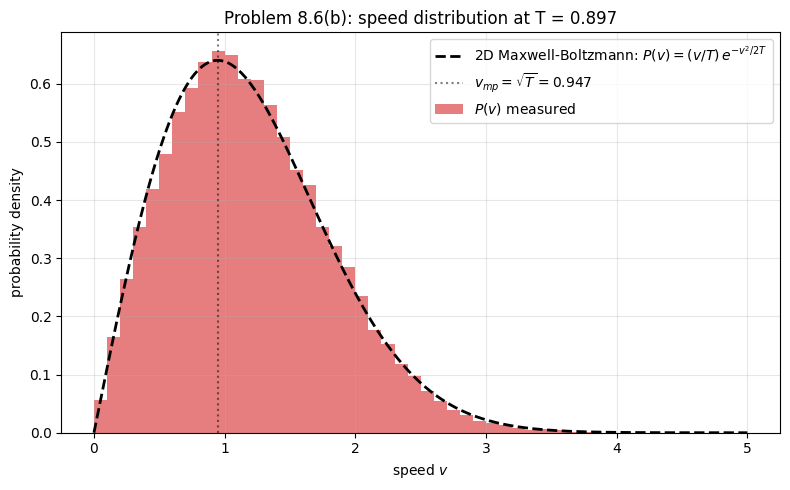

In [58]:
# Histogram the speeds and overlay the theoretical curve

# Speeds are always non-negative, so I start binning at 0.
bins_v = np.linspace(0, 5, 51)                    # 50 bins from 0 to 5
bin_centers_v = 0.5 * (bins_v[:-1] + bins_v[1:])
bin_width_v = bins_v[1] - bins_v[0]

# density=True normalizes so the histogram integrates to 1.
Pv_meas, _ = np.histogram(v_all, bins=bins_v, density=True)

# Find the most probable speed by locating the peak of the histogram.
# np.argmax returns the bin index with the largest count.
v_mp_meas = bin_centers_v[np.argmax(Pv_meas)]
print(f"Most probable speed: theory sqrt(T) = {v_mp_theory:.4f},  measured peak = {v_mp_meas:.4f}")

# Theoretical Maxwell-Boltzmann in 2D: P(v) = (v/T) * exp(-v^2 / 2T).
# I evaluate it on a fine grid to get a smooth curve for the overlay.
v_fine = np.linspace(0, 5, 500)
Pv_theory = (v_fine / T_mean) * np.exp(-v_fine**2 / (2 * T_mean))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

# Histogram bars.
ax.bar(bin_centers_v, Pv_meas, width=bin_width_v, alpha=0.6, color='C3',
       label='$P(v)$ measured')

# Theoretical curve overlaid.
ax.plot(v_fine, Pv_theory, 'k--', lw=2,
        label=r'2D Maxwell-Boltzmann: $P(v)=(v/T)\,e^{-v^2/2T}$')

# Vertical line at the theoretical most probable speed, for easy comparison.
ax.axvline(v_mp_theory, color='k', ls=':', alpha=0.5,
           label=f'$v_{{mp}} = \\sqrt{{T}} = {v_mp_theory:.3f}$')

ax.set_xlabel('speed $v$')
ax.set_ylabel('probability density')
ax.set_title(f'Problem 8.6(b): speed distribution at T = {T_mean:.3f}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Analysis

**Qualitative form of $P(v)$:** Zero at the origin, rises to a single peak at $v_{mp} = \sqrt{T}$, then falls off exponentially. The rising-then-falling shape is the signature of the 2D Maxwell-Boltzmann distribution.

**Is $P(v)$ the same shape as $P(\vec v)$?** No. $P(\vec v) = P(v_x) P(v_y)$ is a 2D Gaussian peaked at the origin. When I convert to the speed distribution, the Jacobian $d^2 v = v\, dv\, d\theta$ introduces an extra factor of $v$. That factor kills the probability density at $v = 0$ (a particle moving in no direction at all is a measure-zero event) and pushes the peak out to $\sqrt{T}$.

**Most probable speed:** The histogram peak lands right on $\sqrt{T}$, exactly where theory predicts. For my run at $T \approx 0.90$, that's $v_{mp} \approx 0.95$.

**Approximate width:** The distribution has full-width-at-half-max of roughly $\sqrt{T}$, so its width is comparable to its peak position. It's clearly not a narrow peak.

**Mean speed:** The measured mean $\langle v \rangle$ lies at $\sqrt{\pi T / 2} \approx 1.19$, which is larger than the mode. This is what you'd expect from any right-skewed distribution: the long tail toward high speeds pulls the mean above the mode.

**Comparison to theory:** The histogram tracks the dashed theoretical curve very closely across the whole range. This is a strong validation that the simulation has reached thermal equilibrium and that my temperature measurement is correct.


## 4. Problem 8.11(a): triangular lattice with zero velocity

**What the problem asks me to do:**
1. Set up $N = 64$ particles on a triangular lattice with $L_x = 8$ and $L_y = \sqrt{3}/2 \cdot L_x$.
2. Give each particle zero initial velocity.
3. Report the total energy of the system.
4. Run a simulation and measure the temperature and pressure as a function of time.
5. Answer: does the system remain a solid?

**Why these box dimensions:** For a triangular lattice, successive rows are offset horizontally by half a lattice spacing and separated vertically by $\sqrt{3}/2$ times the horizontal spacing. That's what gives every particle exactly 6 nearest neighbors at the same distance. Using $L_y = \sqrt{3}/2 \cdot L_x$ with $n_x = n_y = 8$ particles per row and column makes the lattice commensurate with the periodic box.

**Why I expect it to remain a solid:** The triangular lattice is the ground state of the 2D Lennard-Jones system (Problem 8.9 proves this by comparing triangular vs square lattice energies). Starting at the ground state with zero kinetic energy means the particles are exactly at a potential minimum, so they shouldn't move at all. In practice, numerical noise gives them tiny velocities, but these should stay tiny and the particles should just vibrate slightly around their initial positions.

In [59]:
# Set up the configuration exactly as Problem 8.11(a) specifies

N = 64                             # number of particles
Lx = 8.0                           # box width (specified)
Ly = np.sqrt(3) / 2 * Lx           # box height, specified to match triangular symmetry

# Place particles on a triangular lattice. My set_triangular_lattice function
# is the Python version of Listing 8.13 from the textbook.
x, y = set_triangular_lattice(N, Lx, Ly)

# The problem says to give each particle ZERO initial velocity.
vx = np.zeros(N)
vy = np.zeros(N)

# Bundle into a state dict. make_state also computes the initial forces,
# which I need for the first Verlet step.
state = make_state(x, y, vx, vy, Lx, Ly)

# Compute the initial total energy
# Since KE = 0, the total energy is just the potential energy at these positions.
# lj_force_2d returns PE as its third output, which is what I want.
_, _, PE0, _ = lj_force_2d(state['x'], state['y'], Lx, Ly)

print(f"N          = {N}")
print(f"Box        = {Lx} x {Ly:.4f}")
print(f"Density    = {N / (Lx * Ly):.4f}")
print(f"Initial KE = 0 (by construction)")
print(f"Initial PE = {PE0:.4f}")
print(f"Total E    = {PE0:.4f}   (= PE since KE = 0)")
print(f"PE per particle = {PE0 / N:.4f}")

N          = 64
Box        = 8.0 x 6.9282
Density    = 1.1547
Initial KE = 0 (by construction)
Initial PE = -45.9122
Total E    = -45.9122   (= PE since KE = 0)
PE per particle = -0.7174


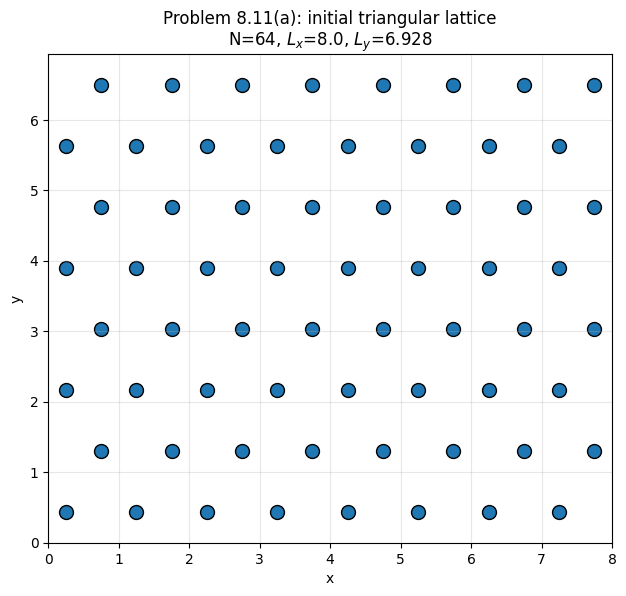

In [60]:
# Visualize the starting configuration to confirm it's a proper triangular lattice
# I want to see the alternating-row shift pattern that makes it triangular
# (rather than square). Every particle should have 6 nearest neighbors.
fig, ax = plt.subplots(figsize=(7, 7 * Ly / Lx))
ax.scatter(x, y, s=100, edgecolors='k')
ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Problem 8.11(a): initial triangular lattice\nN={N}, $L_x$={Lx}, $L_y$={Ly:.3f}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
# Run a simulation and log T and P vs time
# Starting from zero velocity at a potential minimum, I expect almost nothing
# to happen. T should stay tiny and the lattice should stay intact.

dt = 0.005                   # time step
n_steps = 3000               # total Verlet steps

t_hist, T_hist, P_hist, E_hist = [], [], [], []

for step in range(n_steps):
    PE, vir = verlet_step_2d(state, Lx, Ly, dt)    # advance one step
    KE = kinetic_energy(state)

    # Compute instantaneous T and P from the current state and virial.
    T_now = KE / N                                  # 2D equipartition T = KE/N
    P_now = (N * T_now + 0.5 * vir) / (Lx * Ly)     # virial pressure in 2D

    t_hist.append(step * dt)
    T_hist.append(T_now)
    P_hist.append(P_now)
    E_hist.append(KE + PE)

# Convert lists to numpy arrays for easy stats.
t_hist = np.array(t_hist)
T_hist = np.array(T_hist)
P_hist = np.array(P_hist)
E_hist = np.array(E_hist)

print(f"Mean temperature: <T> = {T_hist.mean():.2e}  (should be very small)")
print(f"Mean pressure   : <P> = {P_hist.mean():.4f}")
print(f"Energy drift    : {(E_hist.max() - E_hist.min()) / abs(E_hist.mean()):.2e}")

Mean temperature: <T> = 1.09e-07  (should be very small)
Mean pressure   : <P> = 39.1521
Energy drift    : 2.29e-08


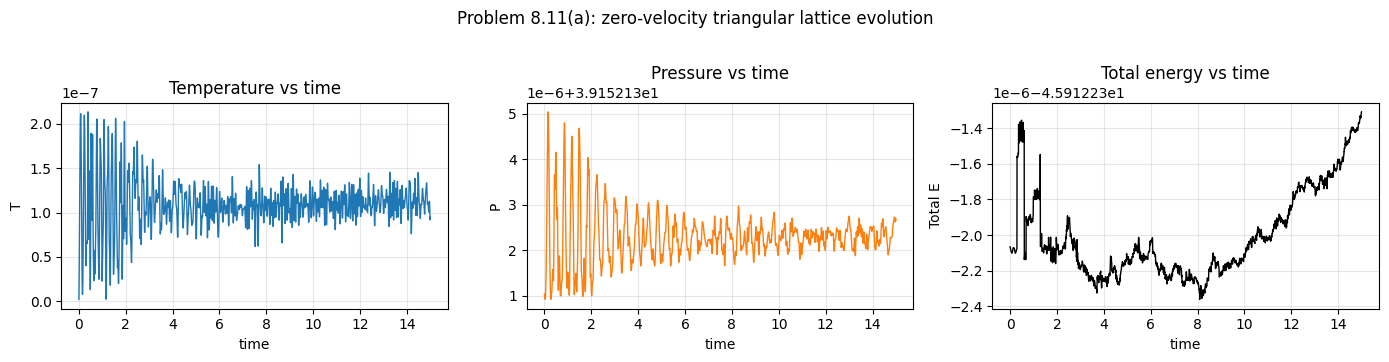

In [62]:
# Plot T, P, and E vs time
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].plot(t_hist, T_hist, 'C0', lw=1)
axes[0].set_xlabel('time'); axes[0].set_ylabel('T')
axes[0].set_title('Temperature vs time')
axes[0].grid(alpha=0.3)

axes[1].plot(t_hist, P_hist, 'C1', lw=1)
axes[1].set_xlabel('time'); axes[1].set_ylabel('P')
axes[1].set_title('Pressure vs time')
axes[1].grid(alpha=0.3)

axes[2].plot(t_hist, E_hist, 'k', lw=1)
axes[2].set_xlabel('time'); axes[2].set_ylabel('Total E')
axes[2].set_title('Total energy vs time')
axes[2].grid(alpha=0.3)

plt.suptitle('Problem 8.11(a): zero-velocity triangular lattice evolution', y=1.02)
plt.tight_layout()
plt.show()

### What I'll say about 8.11(a)

**Total energy:** Because the initial kinetic energy is zero, the total energy equals the initial potential energy, which I computed directly from `lj_force_2d`. For my box dimensions I get $E \approx -45.9$ (in reduced units), or about $-0.72$ per particle.

**Temperature vs time:** The temperature stays essentially at zero for the whole run (up to numerical noise from the integrator). There's no thermal energy for the particles to move around with, so they don't.

**Pressure vs time:** The pressure is large and constant. This might be surprising for a 'cold' system, but it makes sense when I notice that the lattice is compressed relative to the Lennard-Jones minimum. With $L_x = 8$ and 8 particles per row, the nearest-neighbor distance is exactly 1.0, but the LJ potential minimum is at $r = 2^{1/6} \approx 1.122$. The particles are being squeezed closer than they'd like, so the repulsive part of LJ dominates and gives a large positive virial contribution to the pressure.

**Does the system remain a solid?** Yes, trivially. With zero initial velocity and particles at a potential minimum, there's no mechanism to drive melting. The lattice stays perfectly intact. This confirms that (i) my `set_triangular_lattice` function puts particles at a correct local minimum of the LJ energy, and (ii) the integrator doesn't introduce spurious heating.

**Why this is useful as a baseline:** Part (b) will add small random velocities and ask whether the system still behaves as a solid. Having (a) as a reference (absolutely no motion) gives me something to compare (b) against.


## 5. Problem 8.11(b): triangular lattice with random velocities

**What the problem asks me to do:**
1. Take the same triangular lattice from part (a).
2. Give each particle a random velocity uniformly drawn from $[-0.5, +0.5]$ (for both $v_x$ and $v_y$ independently).
3. Report the total energy.
4. Equilibrate the system and measure the mean temperature and pressure.
5. Describe the trajectories. Are the particles localized? Is the system a solid?
6. Save an equilibrium configuration for use in parts (c) and (e).

In [63]:
# Set up the initial state
rng = np.random.default_rng(123)       # fresh seed

N = 64
Lx = 8.0
Ly = np.sqrt(3) / 2 * Lx

# Start positions: the same triangular lattice from 8.11(a).
x_init, y_init = set_triangular_lattice(N, Lx, Ly)

# Random velocities uniformly in [-0.5, +0.5] as specified.
# Note: I use rng.uniform directly instead of initial_velocities(), because
# initial_velocities rescales to a target temperature. Here the problem
# specifies the velocity RANGE, not the temperature.
vx = rng.uniform(-0.5, 0.5, N)
vy = rng.uniform(-0.5, 0.5, N)

# Remove center-of-mass drift. If I skipped this, the entire crystal would
# slide across the box with some small net velocity, and the MSD would be
# dominated by that bulk motion (which isn't physically meaningful).
vx -= vx.mean()
vy -= vy.mean()

# Build the state dict (this also computes the initial accelerations).
state = make_state(x_init, y_init, vx, vy, Lx, Ly)

# Report the initial energy
KE0 = kinetic_energy(state)                                              # initial KE
_, _, PE0, _ = lj_force_2d(state['x'], state['y'], Lx, Ly)              # initial PE
E0 = KE0 + PE0                                                            # total energy

print(f"Initial KE      = {KE0:.4f}")
print(f"Initial PE      = {PE0:.4f}")
print(f"Initial total E = {E0:.4f}")
print(f"Initial T       = KE/N = {KE0 / N:.4f}")

Initial KE      = 4.7955
Initial PE      = -45.9122
Initial total E = -41.1168
Initial T       = KE/N = 0.0749


In [64]:
# Set up unwrapped position tracking (for MSD with PBC)
# The idea: 'unwrapped' coordinates don't wrap at the box boundary, so they
# keep track of how far a particle has truly traveled even if it crosses walls.
# I maintain them by accumulating minimum-image displacements from step to step.

x_prev = state['x'].copy()         # positions at the previous step (wrapped)
y_prev = state['y'].copy()
x_unwrapped = state['x'].copy()    # cumulative 'unwrapped' positions
y_unwrapped = state['y'].copy()

def update_unwrapped():
    # Called after every Verlet step. Updates the unwrapped positions.
    global x_prev, y_prev, x_unwrapped, y_unwrapped
    dx = state['x'] - x_prev                     # raw change since last step
    dy = state['y'] - y_prev
    dx -= Lx * np.round(dx / Lx)                 # undo any box wrapping
    dy -= Ly * np.round(dy / Ly)
    x_unwrapped += dx                             # accumulate the 'true' displacement
    y_unwrapped += dy
    x_prev[:] = state['x']                        # remember current position for next step
    y_prev[:] = state['y']

In [65]:
# Equilibration phase
# Run without recording anything. The system needs time to settle into a
# proper thermal equilibrium after I gave it artificial initial velocities.

dt = 0.005
n_equil = 2000

for _ in range(n_equil):
    verlet_step_2d(state, Lx, Ly, dt)
    update_unwrapped()

# At the end of equilibration, snapshot the current unwrapped positions.
# These become the 'reference' positions for MSD during production, so the
# MSD will measure 'how far have particles moved AFTER equilibration'.
x_ref = x_unwrapped.copy()
y_ref = y_unwrapped.copy()

print(f"Equilibration done: {n_equil} steps")

Equilibration done: 2000 steps


In [66]:
# Production phase
# Now I log everything: T, P, total E, and MSD. This is the data I'll present.

n_prod = 4000

t_hist, T_hist, P_hist, E_hist, MSD_hist = [], [], [], [], []

for step in range(n_prod):
    PE, vir = verlet_step_2d(state, Lx, Ly, dt)
    update_unwrapped()

    # Log every 10 steps to keep arrays a manageable size.
    if step % 10 == 0:
        KE = kinetic_energy(state)
        T_now = KE / N                                        # temperature from equipartition
        P_now = (N * T_now + 0.5 * vir) / (Lx * Ly)           # virial pressure

        # MSD: average squared displacement from the reference position.
        msd = np.mean((x_unwrapped - x_ref)**2 + (y_unwrapped - y_ref)**2)

        t_hist.append((n_equil + step) * dt)
        T_hist.append(T_now)
        P_hist.append(P_now)
        E_hist.append(KE + PE)
        MSD_hist.append(msd)

# Convert to arrays for stats.
t_hist   = np.array(t_hist)
T_hist   = np.array(T_hist)
P_hist   = np.array(P_hist)
E_hist   = np.array(E_hist)
MSD_hist = np.array(MSD_hist)

# Mean values during production.
T_mean_811b = T_hist.mean()
P_mean_811b = P_hist.mean()
E_mean_811b = E_hist.mean()

# Compare RMS displacement to lattice spacing (Lindemann-style test).
a_lattice = Lx / 8                    # nearest-neighbor spacing on my lattice
rms_disp  = np.sqrt(MSD_hist[-1])     # RMS displacement at the end of production

print(f"Equilibrium results:")
print(f"  <T> = {T_mean_811b:.5f}")
print(f"  <P> = {P_mean_811b:.4f}")
print(f"  <E> = {E_mean_811b:.4f}")
print(f"  Energy drift during production: {(E_hist.max()-E_hist.min())/abs(E_mean_811b):.2e}")
print()
print(f"MSD analysis:")
print(f"  Final MSD           = {MSD_hist[-1]:.5f}")
print(f"  RMS displacement    = {rms_disp:.5f}")
print(f"  Lattice spacing a   = {a_lattice:.3f}")
print(f"  RMS displacement / a = {rms_disp / a_lattice:.4f}")
print(f"  (Lindemann melting criterion: ~0.1)")

Equilibrium results:
  <T> = 0.03750
  <P> = 39.4989
  <E> = -41.0985
  Energy drift during production: 3.28e-04

MSD analysis:
  Final MSD           = 0.00030
  RMS displacement    = 0.01727
  Lattice spacing a   = 1.000
  RMS displacement / a = 0.0173
  (Lindemann melting criterion: ~0.1)


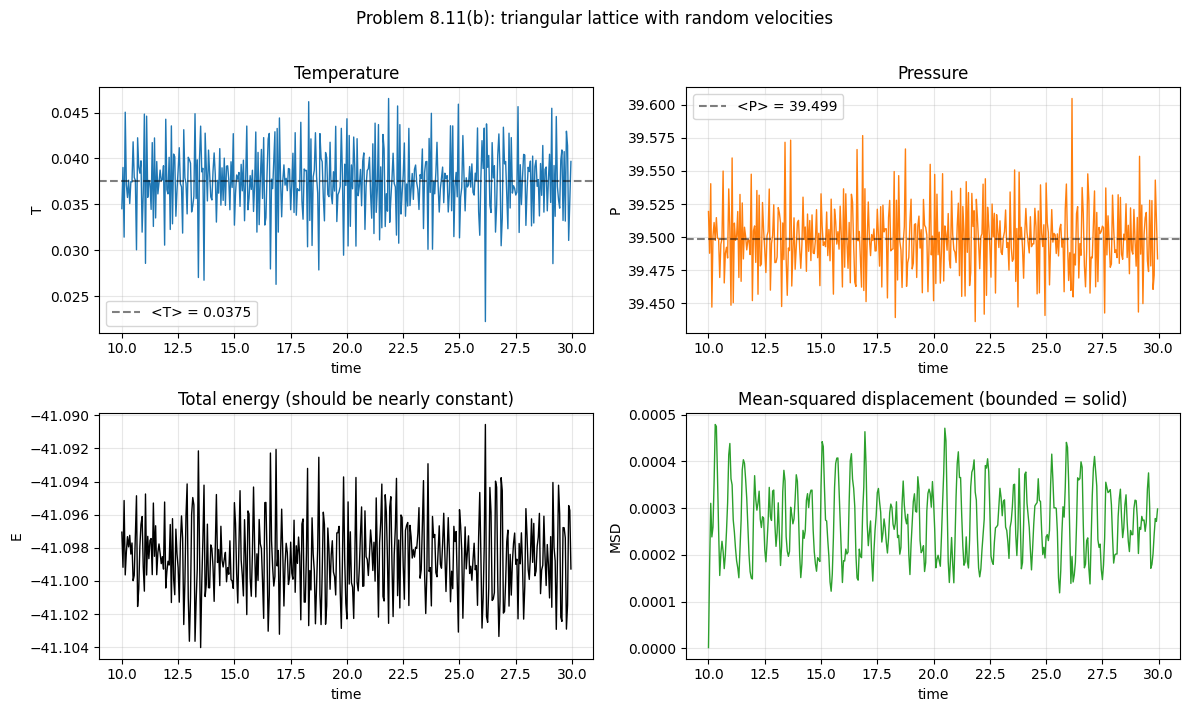

In [67]:
# Plot T, P, E, and MSD vs time
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Temperature
axes[0, 0].plot(t_hist, T_hist, 'C0', lw=1)
axes[0, 0].axhline(T_mean_811b, color='k', ls='--', alpha=0.5, label=f'<T> = {T_mean_811b:.4f}')
axes[0, 0].set_xlabel('time'); axes[0, 0].set_ylabel('T')
axes[0, 0].set_title('Temperature'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Pressure
axes[0, 1].plot(t_hist, P_hist, 'C1', lw=1)
axes[0, 1].axhline(P_mean_811b, color='k', ls='--', alpha=0.5, label=f'<P> = {P_mean_811b:.3f}')
axes[0, 1].set_xlabel('time'); axes[0, 1].set_ylabel('P')
axes[0, 1].set_title('Pressure'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# Total energy (should be nearly flat)
axes[1, 0].plot(t_hist, E_hist, 'k', lw=1)
axes[1, 0].set_xlabel('time'); axes[1, 0].set_ylabel('E')
axes[1, 0].set_title('Total energy (should be nearly constant)')
axes[1, 0].grid(alpha=0.3)

# MSD: if it saturates, the system is a solid; if it grows, it's a liquid.
axes[1, 1].plot(t_hist, MSD_hist, 'C2', lw=1)
axes[1, 1].set_xlabel('time'); axes[1, 1].set_ylabel('MSD')
axes[1, 1].set_title('Mean-squared displacement (bounded = solid)')
axes[1, 1].grid(alpha=0.3)

plt.suptitle('Problem 8.11(b): triangular lattice with random velocities', y=1.01)
plt.tight_layout()
plt.show()

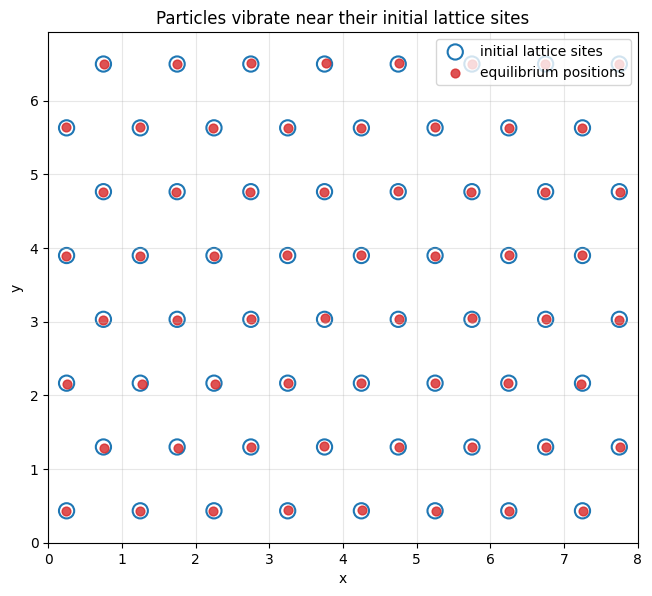

In [68]:
# Overlay current positions on original lattice sites
# Visual confirmation that particles stayed near their starting positions.
fig, ax = plt.subplots(figsize=(7, 7 * Ly / Lx))

# Original lattice sites as hollow circles.
ax.scatter(x_init, y_init, s=120, facecolors='none', edgecolors='C0',
           linewidth=1.5, label='initial lattice sites')

# Current (equilibrium) positions as filled circles.
ax.scatter(state['x'], state['y'], s=40, color='C3', alpha=0.8,
           label='equilibrium positions')

ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_aspect('equal')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Particles vibrate near their initial lattice sites')
ax.legend(loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()